In [9]:
import sys
sys.path.append('../')
import os
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from src.IO import ExperimentLoader
from src.environment import LigandEnvironment, LogNormalConcentration
from src.physics import BinaryReceptor
from objectives.loss import ExactInformationLoss
from src import plot_latent_umap

PARAMETER SWEEP
The script runs a massive parallelized sweep across varying levels of environmental complexity and genetic restrictions:
- `n_families` (Environmental Complexity): [1, 2, 3, 5, 10, 20]
- `latent_dim` (Chemical Space Dimension): [3, 7, 10]
- `n_units` (Number of Available Genes): [1, 2, 3, 5, 7, 8, 10, 12, 15, 20, 30, 50]
- `n_samples` (Trials): 5 independent simulation runs per configuration to measure statistical variance and stability.

OUTPUTS
Data is recursively saved to: `/app/data/families_<n_families>/dim_<latent_dim>/n_units_<n_units>/sample_<sample_id>/`
Each run folder generates:
- `config.json`: The specific parameters for the trial.
- `stats.csv`: Epoch-by-epoch training metrics, including the array's differential entropy and mean receptor distances.
- `best_model.pt`: The optimized neural network/environment weights.
- `test_results.json`: Independent post-training evaluation measurements of the array's entropy, used to calculate confidence intervals and standard deviations.

By increasing both the number of families and the latent dimension, the simulation assesses how effectively combinatorial receptor arrays (homomeric vs. heteromeric) can break the "discretization bottleneck" and utilize their full theoretical coding capacity in highly complex environments.

In [13]:
# Load all experiments across the parameter sweep
base_data_path = Path("../data")
experiments = {}

for f_dir in base_data_path.glob("families_*"):
    n_families = int(f_dir.name.split("_")[1])
    for d_dir in f_dir.glob("dim_*"):
        latent_dim = int(d_dir.name.split("_")[1])
        for u_dir in d_dir.glob("n_units_*"):
            n_units = int(u_dir.name.split("_")[2])
            config_key = (n_families, latent_dim, n_units)
            
            if config_key not in experiments:
                experiments[config_key] = {'samples': [], 'test_entropies': []}
            
            for sample_dir in u_dir.glob("sample_*"):
                try:
                    loader = ExperimentLoader(base_path=str(u_dir), experiment_name=sample_dir.name)
                    env, physics, loss_fn, receptor_indices, stats_df, config = loader.load_objects(filename="best_model.pt")
                    # Load test results for standard deviation estimation
                    test_json_path = sample_dir / "test_results.json"
                    test_entropies = []
                    if test_json_path.exists():
                        with open(test_json_path, "r") as f:
                            test_entropies = json.load(f).get("test_entropies", [])
                    experiments[config_key]['samples'].append({
                        'env': env, 'physics': physics, 'receptor_indices': receptor_indices,
                        'stats_df': stats_df, 'test_entropies': test_entropies, 'config': config
                    })
                    experiments[config_key]['test_entropies'].extend(test_entropies)
                except Exception as e:
                    print(e)
                    pass

print(f"Loaded {len(experiments)} unique configurations.")

Auto-discovered latest run: sample_0_20260410_104656
Auto-discovered latest run: sample_4_20260410_110832
Auto-discovered latest run: sample_2_20260410_105808
Auto-discovered latest run: sample_1_20260410_105247
Auto-discovered latest run: sample_3_20260410_110320
Auto-discovered latest run: sample_2_20260410_101808
Auto-discovered latest run: sample_1_20260410_101736
Auto-discovered latest run: sample_4_20260410_101916
Auto-discovered latest run: sample_3_20260410_101841
Auto-discovered latest run: sample_0_20260410_101704
Auto-discovered latest run: sample_3_20260410_102150
Auto-discovered latest run: sample_2_20260410_102111
Auto-discovered latest run: sample_4_20260410_102234
Auto-discovered latest run: sample_1_20260410_102031
Auto-discovered latest run: sample_0_20260410_101952
Auto-discovered latest run: sample_0_20260410_102322
Auto-discovered latest run: sample_3_20260410_102603
Auto-discovered latest run: sample_2_20260410_102509
Auto-discovered latest run: sample_1_20260410_

In [23]:
# Example: viewing stats for Families=10, Dim=10, Units=10 (Sample 0)
if (20, 10, 10) in experiments and len(experiments[(20, 10, 10)]['samples']) > 0:
    display(experiments[(20, 10, 10)]['samples'][0]['stats_df'].head())
else:
    print('not in the folder')

,full_array_entropy,mean_receptor_distance,conditional_entropy_family,mutual_information_family,conditional_entropy_concentration,mutual_information_concentration,lr,epoch
0,1.679416,4.638725,0.815461,0.857485,0.713365,0.969848,0.05,0
1,3.565976,3.231613,1.780045,1.791388,1.483199,2.074589,0.05,1
2,4.058759,3.445713,1.990062,2.065970,1.814629,2.257635,0.05,2
3,4.296960,3.744618,2.070765,2.230036,2.002799,2.294881,0.05,3
4,4.451094,3.995536,2.141939,2.300143,2.146643,2.299513,0.05,4


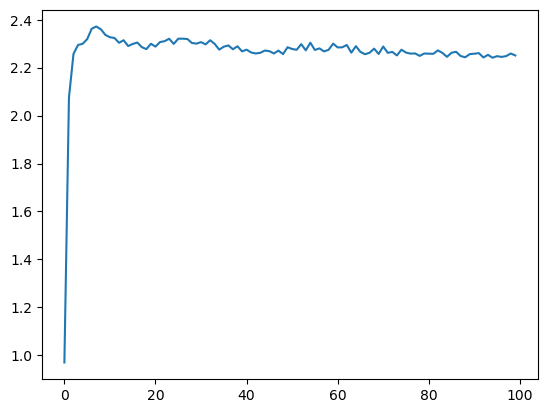

In [25]:
plt.plot(experiments[(20, 10, 10)]['samples'][0]['stats_df']['mutual_information_concentration'])

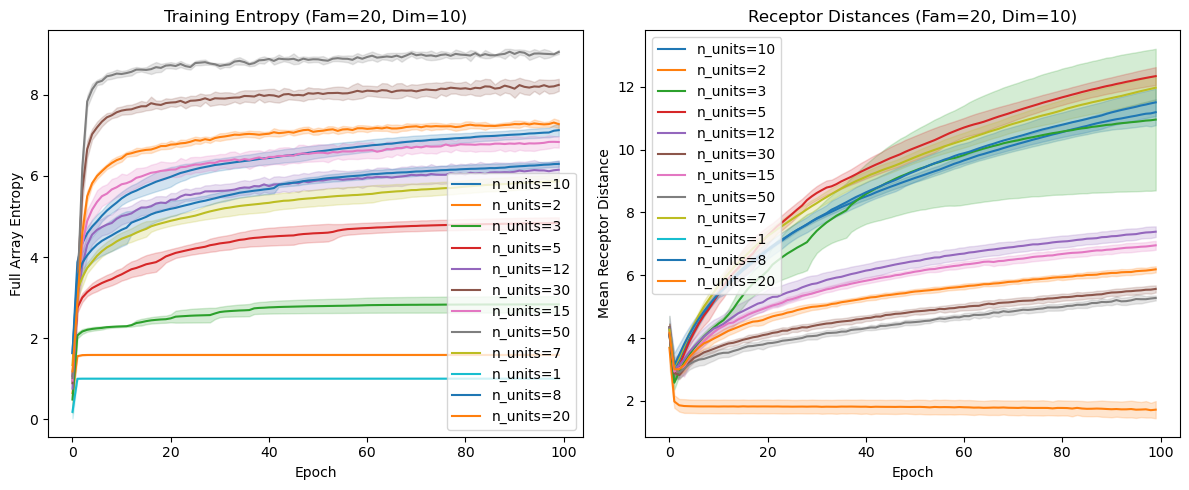

In [21]:
# Plot the training metrics (Mean & Std Dev) for a specific configuration
target_families = 20
target_dim = 10

fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

for config_key, exp_data in experiments.items():
    n_families, latent_dim, n_units = config_key
    if n_families != target_families or latent_dim != target_dim or not exp_data['samples']:
        continue
    
    all_entropies = [s['stats_df']['full_array_entropy'].values for s in exp_data['samples']]
    all_distances = [s['stats_df']['mean_receptor_distance'].values for s in exp_data['samples']]
    epochs = exp_data['samples'][0]['stats_df']['epoch'].values
    
    # Standardize length if samples got interrupted
    min_len = min(len(e) for e in all_entropies)
    all_entropies = [e[:min_len] for e in all_entropies]
    all_distances = [d[:min_len] for d in all_distances]
    epochs = epochs[:min_len]
    
    mean_ent = np.mean(all_entropies, axis=0)
    std_ent = np.std(all_entropies, axis=0)
    mean_dist = np.mean(all_distances, axis=0)
    std_dist = np.std(all_distances, axis=0)
    
    p = ax[0].plot(epochs, mean_ent, label=f'n_units={n_units}')
    ax[0].fill_between(epochs, mean_ent - std_ent, mean_ent + std_ent, color=p[0].get_color(), alpha=0.2)
    
    p = ax[1].plot(epochs, mean_dist, label=f'n_units={n_units}')
    ax[1].fill_between(epochs, mean_dist - std_dist, mean_dist + std_dist, color=p[0].get_color(), alpha=0.2)

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Full Array Entropy')
ax[0].set_title(f'Training Entropy (Fam={target_families}, Dim={target_dim})')
ax[0].legend()

ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Mean Receptor Distance')
ax[1].set_title(f'Receptor Distances (Fam={target_families}, Dim={target_dim})')
ax[1].legend()

plt.tight_layout()
plt.show()

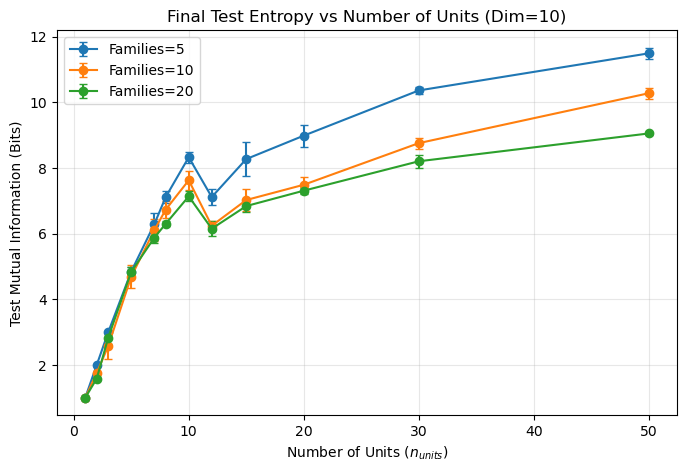


Fitting UMAP for Fam=20, Dim=10, Units=10 (Sample 0)...
Fitting UMAP... (This may take a few seconds)


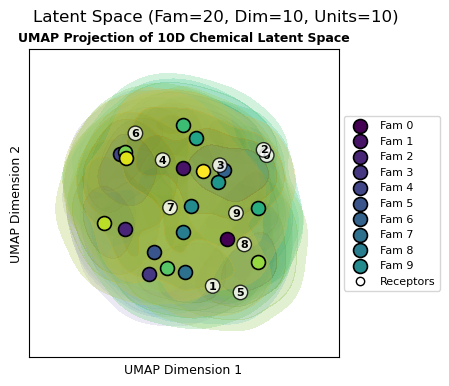


Fitting UMAP for Fam=20, Dim=10, Units=20 (Sample 0)...
Fitting UMAP... (This may take a few seconds)


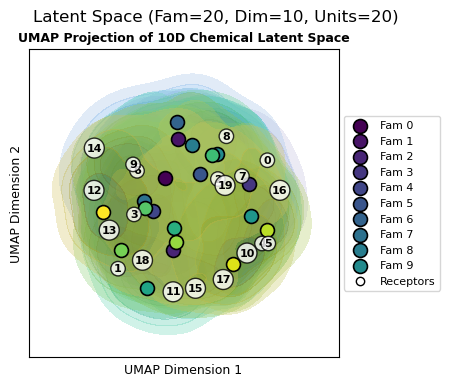

In [22]:
# Plot final Test Entropy (Mean +/- Std) vs n_units for different Families
fig, ax = plt.subplots(figsize=(8, 5))
families_to_plot = [1, 5, 10, 20]

for fam in families_to_plot:
    x_units, y_means, y_stds = [], [], []
    for config_key, exp_data in experiments.items():
        n_families, latent_dim, n_units = config_key
        if n_families == fam and latent_dim == target_dim and len(exp_data['test_entropies']) > 0:
            x_units.append(n_units)
            y_means.append(np.mean(exp_data['test_entropies']))
            y_stds.append(np.std(exp_data['test_entropies']))
    
    if x_units:
        sorted_indices = np.argsort(x_units)
        x_units = np.array(x_units)[sorted_indices]
        y_means = np.array(y_means)[sorted_indices]
        y_stds = np.array(y_stds)[sorted_indices]
        ax.errorbar(x_units, y_means, yerr=y_stds, marker='o', capsize=3, label=f'Families={fam}')

ax.set_xlabel('Number of Units ($n_{units}$)')
ax.set_ylabel('Test Mutual Information (Bits)')
ax.set_title(f'Final Test Entropy vs Number of Units (Dim={target_dim})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Plot the latent space visualization for a specific best sample
units_to_plot = [10, 20]
for units in units_to_plot:
    config_key = (target_families, target_dim, units)
    if config_key in experiments and len(experiments[config_key]['samples']) > 0:
        exp_data = experiments[config_key]['samples'][0]
        print(f"\nFitting UMAP for Fam={target_families}, Dim={target_dim}, Units={units} (Sample 0)...")
        fig, ax = plot_latent_umap(exp_data['env'], exp_data['receptor_indices'])
        fig.suptitle(f"Latent Space (Fam={target_families}, Dim={target_dim}, Units={units})")
        plt.show()

In [29]:
units_to_plot = [10, 20]
for units in units_to_plot:
    config_key = (target_families, target_dim, units)
    if config_key in experiments and len(experiments[config_key]['samples']) > 0:
        print(exp_data['env'].shape_sigma)
        print(exp_data['env'].avg_family_distance)
        print(exp_data['env'].n_families)

0.5
5.0
20
0.5
5.0
20
